# Fuzzy Logic Support-Triage Simulation System

## Course: BS in Computer Science
## Subject: Intelligent Systems
## Submission: Fuzzy Logic-Based Mental Health Support Priority Assessment

### Purpose
This system simulates a fuzzy inference engine that recommends a support action level based on student indicators. It models human-like decision-making under uncertainty without diagnosing or replacing professional judgment.

**Important Ethical Note:** This is an educational simulation only and must not be used to diagnose conditions or replace clinical judgment. Licensed professionals must always perform real mental health assessments.

## System Overview

### Output: Support Priority / Recommended Action Levels
- **0–25:** Monitor & Self-care (check-in, coping skills, peer support)
- **25–50:** Schedule Counseling (non-urgent guidance counseling)
- **50–75:** Urgent Referral (same-day/next-day mental health professional)
- **75–100:** Emergency Protocol (immediate safety support / crisis response)

### Input Variables (Student Indicators)
1. **Symptom Severity (PHQ-9 Score: 0–27)**
   - Low: 0–9 | Moderate: 7–17 | High: 15–27

2. **Functional Impairment (0–10)**
   - Mild: 0–3 | Moderate: 2–7 | Severe: 6–10

3. **Suicidal Risk Indicators (0–10)**
   - None: 0–1 | Some: 1–6 | High: 5–10

4. **Duration of Symptoms (0–12 weeks)**
   - Short: 0–2 | Medium: 2–6 | Long: 6–12

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# STEP 1: DEFINE MEMBERSHIP FUNCTIONS
# ============================================================================

class MembershipFunction:
    """Base class for membership functions"""
    def __call__(self, x):
        raise NotImplementedError

class TriangularMF(MembershipFunction):
    """Triangular membership function"""
    def __init__(self, a, b, c):
        self.a = a  # left
        self.b = b  # peak
        self.c = c  # right
    
    def __call__(self, x):
        if x <= self.a or x >= self.c:
            return 0.0
        elif x == self.b:
            return 1.0
        elif x < self.b:
            return (x - self.a) / (self.b - self.a)
        else:
            return (self.c - x) / (self.c - self.b)

class TrapezoidalMF(MembershipFunction):
    """Trapezoidal membership function"""
    def __init__(self, a, b, c, d):
        self.a = a
        self.b = b
        self.c = c
        self.d = d
    
    def __call__(self, x):
        if x <= self.a or x >= self.d:
            return 0.0
        elif self.a < x < self.b:
            return (x - self.a) / (self.b - self.a)
        elif self.b <= x <= self.c:
            return 1.0
        else:
            return (self.d - x) / (self.d - self.c)

class SigmoidMF(MembershipFunction):
    """Sigmoid membership function"""
    def __init__(self, center, width):
        self.center = center
        self.width = width
    
    def __call__(self, x):
        return 1.0 / (1.0 + np.exp(-(x - self.center) / self.width))

# ============================================================================
# STEP 2: DEFINE FUZZY SETS FOR EACH INPUT AND OUTPUT
# ============================================================================

# Symptom Severity (PHQ-9: 0-27)
symptom_severity_sets = {
    'Low': TriangularMF(0, 4.5, 9),
    'Moderate': TriangularMF(7, 12, 17),
    'High': TriangularMF(15, 22, 27)
}

# Functional Impairment (0-10)
functional_impairment_sets = {
    'Mild': TriangularMF(0, 1.5, 3),
    'Moderate': TriangularMF(2, 5, 7),
    'Severe': TriangularMF(6, 8, 10)
}

# Suicidal Risk (0-10)
suicidal_risk_sets = {
    'None': TriangularMF(0, 0.5, 1),
    'Some': TriangularMF(1, 3.5, 6),
    'High': TriangularMF(5, 7.5, 10)
}

# Duration of Symptoms (0-12 weeks)
duration_sets = {
    'Short': TriangularMF(0, 1, 2),
    'Medium': TriangularMF(2, 4, 6),
    'Long': TriangularMF(6, 9, 12)
}

# Output: Action Level (0-100)
action_level_sets = {
    'Monitor': TriangularMF(0, 15, 30),
    'Counseling': TriangularMF(20, 40, 55),
    'Urgent': TriangularMF(45, 60, 80),
    'Emergency': TriangularMF(75, 87.5, 100)
}

print("✓ Membership functions defined for all inputs and outputs")

✓ Membership functions defined for all inputs and outputs


In [3]:
# ============================================================================
# STEP 3: DEFINE FUZZY RULES (IF-THEN statements)
# ============================================================================

def apply_rule(premise_truth_values, consequent_set):
    """
    Apply a single fuzzy rule
    premise_truth_values: list of truth values from antecedent conditions
    consequent_set: the output membership set (as string key)
    Returns: (rule_weight, output_set_name)
    """
    # Use MIN operator for AND conditions
    rule_weight = min(premise_truth_values)
    return rule_weight, consequent_set

# Fuzzy Rules (14 rules as recommended)
# Rule format: (condition_function, output_label, description)

def rule_1(severity, impairment, risk, duration):
    """Safety-first: High suicidal risk → Emergency"""
    weight = risk['High']
    return apply_rule([weight], 'Emergency')

def rule_2(severity, impairment, risk, duration):
    """Safety: Some risk + Severe impairment → Emergency"""
    weight = min(risk['Some'], impairment['Severe'])
    return apply_rule([weight], 'Emergency')

def rule_3(severity, impairment, risk, duration):
    """Safety: Some risk + High symptoms → Urgent"""
    weight = min(risk['Some'], severity['High'])
    return apply_rule([weight], 'Urgent')

def rule_4(severity, impairment, risk, duration):
    """High symptoms + Severe impairment → Urgent"""
    weight = min(severity['High'], impairment['Severe'])
    return apply_rule([weight], 'Urgent')

def rule_5(severity, impairment, risk, duration):
    """High symptoms + Long duration → Urgent"""
    weight = min(severity['High'], duration['Long'])
    return apply_rule([weight], 'Urgent')

def rule_6(severity, impairment, risk, duration):
    """Severe impairment + Long duration → Urgent"""
    weight = min(impairment['Severe'], duration['Long'])
    return apply_rule([weight], 'Urgent')

def rule_7(severity, impairment, risk, duration):
    """Moderate symptoms + Moderate impairment → Counseling"""
    weight = min(severity['Moderate'], impairment['Moderate'])
    return apply_rule([weight], 'Counseling')

def rule_8(severity, impairment, risk, duration):
    """Moderate symptoms + Medium duration → Counseling"""
    weight = min(severity['Moderate'], duration['Medium'])
    return apply_rule([weight], 'Counseling')

def rule_9(severity, impairment, risk, duration):
    """Moderate impairment + Long duration → Urgent (escalated)"""
    weight = min(impairment['Moderate'], duration['Long'])
    return apply_rule([weight], 'Urgent')

def rule_10(severity, impairment, risk, duration):
    """Low symptoms + Mild impairment → Monitor"""
    weight = min(severity['Low'], impairment['Mild'])
    return apply_rule([weight], 'Monitor')

def rule_11(severity, impairment, risk, duration):
    """Low symptoms + Short duration → Monitor"""
    weight = min(severity['Low'], duration['Short'])
    return apply_rule([weight], 'Monitor')

def rule_12(severity, impairment, risk, duration):
    """Some risk + Moderate symptoms → Counseling"""
    weight = min(risk['Some'], severity['Moderate'])
    return apply_rule([weight], 'Counseling')

def rule_13(severity, impairment, risk, duration):
    """Some risk + High symptoms → Urgent"""
    weight = min(risk['Some'], severity['High'])
    return apply_rule([weight], 'Urgent')

def rule_14(severity, impairment, risk, duration):
    """Moderate impairment + Moderate symptoms → Counseling"""
    weight = min(impairment['Moderate'], severity['Moderate'])
    return apply_rule([weight], 'Counseling')

# List of all rules
rules = [rule_1, rule_2, rule_3, rule_4, rule_5, rule_6, rule_7, rule_8,
         rule_9, rule_10, rule_11, rule_12, rule_13, rule_14]

rule_descriptions = [
    "High suicidal risk → Emergency",
    "Some risk + Severe impairment → Emergency",
    "Some risk + High symptoms → Urgent",
    "High symptoms + Severe impairment → Urgent",
    "High symptoms + Long duration → Urgent",
    "Severe impairment + Long duration → Urgent",
    "Moderate symptoms + Moderate impairment → Counseling",
    "Moderate symptoms + Medium duration → Counseling",
    "Moderate impairment + Long duration → Urgent",
    "Low symptoms + Mild impairment → Monitor",
    "Low symptoms + Short duration → Monitor",
    "Some risk + Moderate symptoms → Counseling",
    "Some risk + High symptoms → Urgent",
    "Moderate impairment + Moderate symptoms → Counseling"
]

print(f"✓ {len(rules)} Fuzzy Rules Defined:")
for i, desc in enumerate(rule_descriptions, 1):
    print(f"  Rule {i}: {desc}")

✓ 14 Fuzzy Rules Defined:
  Rule 1: High suicidal risk → Emergency
  Rule 2: Some risk + Severe impairment → Emergency
  Rule 3: Some risk + High symptoms → Urgent
  Rule 4: High symptoms + Severe impairment → Urgent
  Rule 5: High symptoms + Long duration → Urgent
  Rule 6: Severe impairment + Long duration → Urgent
  Rule 7: Moderate symptoms + Moderate impairment → Counseling
  Rule 8: Moderate symptoms + Medium duration → Counseling
  Rule 9: Moderate impairment + Long duration → Urgent
  Rule 10: Low symptoms + Mild impairment → Monitor
  Rule 11: Low symptoms + Short duration → Monitor
  Rule 12: Some risk + Moderate symptoms → Counseling
  Rule 13: Some risk + High symptoms → Urgent
  Rule 14: Moderate impairment + Moderate symptoms → Counseling


In [4]:
# ============================================================================
# STEP 4: FUZZY INFERENCE ENGINE & DEFUZZIFICATION
# ============================================================================

def fuzzify_input(value, fuzzy_sets):
    """
    Convert crisp input value to fuzzy membership values
    Returns: dict with membership values for each fuzzy set
    """
    membership_values = {}
    for set_name, mf in fuzzy_sets.items():
        membership_values[set_name] = mf(value)
    return membership_values

def fuzzy_inference(symptom_severity, functional_impairment, suicidal_risk, duration):
    """
    Main fuzzy inference engine
    Input: crisp values for all 4 inputs
    Output: aggregated fuzzy set for output
    """
    # Step 1: Fuzzify all inputs
    severity_membership = fuzzify_input(symptom_severity, symptom_severity_sets)
    impairment_membership = fuzzify_input(functional_impairment, functional_impairment_sets)
    risk_membership = fuzzify_input(suicidal_risk, suicidal_risk_sets)
    duration_membership = fuzzify_input(duration, duration_sets)
    
    # Step 2: Evaluate each rule
    rule_outputs = {}  # {output_label: [weights]}
    
    for rule_func in rules:
        weight, output_label = rule_func(
            severity_membership,
            impairment_membership,
            risk_membership,
            duration_membership
        )
        
        if output_label not in rule_outputs:
            rule_outputs[output_label] = []
        rule_outputs[output_label].append(weight)
    
    # Step 3: Aggregate rule outputs (MAX operator)
    aggregated_weights = {}
    for output_label, weights in rule_outputs.items():
        aggregated_weights[output_label] = max(weights)
    
    return aggregated_weights, severity_membership, impairment_membership, risk_membership, duration_membership

def defuzzify_centroid(aggregated_weights):
    """
    Centroid (Center of Area) defuzzification method
    Converts fuzzy output back to crisp value
    """
    numerator = 0.0
    denominator = 0.0
    
    for output_label, weight in aggregated_weights.items():
        # Get the center of each output fuzzy set
        if output_label == 'Monitor':
            center = 15
        elif output_label == 'Counseling':
            center = 40
        elif output_label == 'Urgent':
            center = 60
        elif output_label == 'Emergency':
            center = 87.5
        else:
            center = 50
        
        numerator += weight * center
        denominator += weight
    
    if denominator == 0:
        return 0.0
    
    return numerator / denominator

def get_action_level(crisp_output):
    """Classify the crisp output into action level category"""
    if crisp_output < 25:
        return "Monitor & Self-care"
    elif crisp_output < 50:
        return "Schedule Counseling"
    elif crisp_output < 75:
        return "Urgent Referral"
    else:
        return "Emergency Protocol"

print("✓ Fuzzy Inference Engine Ready (Fuzzification → Rule Evaluation → Defuzzification)")

✓ Fuzzy Inference Engine Ready (Fuzzification → Rule Evaluation → Defuzzification)


In [5]:
# ============================================================================
# STEP 5: TEST CASES
# ============================================================================

test_cases = [
    {
        'name': 'Case A: Early Mild Symptoms',
        'symptom_severity': 6,      # Low
        'functional_impairment': 2, # Mild
        'suicidal_risk': 0,         # None
        'duration': 1               # Short
    },
    {
        'name': 'Case B: Moderate Persistent Symptoms',
        'symptom_severity': 14,     # Moderate
        'functional_impairment': 5, # Moderate
        'suicidal_risk': 1,         # Some
        'duration': 5               # Medium
    },
    {
        'name': 'Case C: Severe Long-term Impairment',
        'symptom_severity': 20,     # High
        'functional_impairment': 8, # Severe
        'suicidal_risk': 2,         # Some
        'duration': 10              # Long
    },
    {
        'name': 'Case D: High Suicidal Risk (Safety Override)',
        'symptom_severity': 5,      # Low
        'functional_impairment': 2, # Mild
        'suicidal_risk': 8,         # High (OVERRIDE)
        'duration': 1               # Short
    }
]

# Run all test cases
print("=" * 80)
print("FUZZY INFERENCE SYSTEM - TEST RESULTS")
print("=" * 80)

test_results = []

for i, test_case in enumerate(test_cases, 1):
    print(f"\n{'─' * 80}")
    print(f"TEST CASE {i}: {test_case['name']}")
    print(f"{'─' * 80}")
    
    # Input values
    sym = test_case['symptom_severity']
    imp = test_case['functional_impairment']
    risk = test_case['suicidal_risk']
    dur = test_case['duration']
    
    print(f"\nInput Values:")
    print(f"  • Symptom Severity (PHQ-9):    {sym}/27")
    print(f"  • Functional Impairment:       {imp}/10")
    print(f"  • Suicidal Risk Indicators:    {risk}/10")
    print(f"  • Duration of Symptoms:        {dur}/12 weeks")
    
    # Run inference
    aggregated_weights, severity_mem, impairment_mem, risk_mem, duration_mem = fuzzy_inference(sym, imp, risk, dur)
    
    # Defuzzify
    crisp_output = defuzzify_centroid(aggregated_weights)
    action_level = get_action_level(crisp_output)
    
    # Store results
    test_results.append({
        'case': test_case['name'],
        'inputs': (sym, imp, risk, dur),
        'output': crisp_output,
        'action': action_level,
        'aggregated_weights': aggregated_weights
    })
    
    print(f"\nFuzzy Set Membership Strengths:")
    print(f"  Symptom Severity:")
    print(f"    - Low: {severity_mem['Low']:.3f}, Moderate: {severity_mem['Moderate']:.3f}, High: {severity_mem['High']:.3f}")
    print(f"  Functional Impairment:")
    print(f"    - Mild: {impairment_mem['Mild']:.3f}, Moderate: {impairment_mem['Moderate']:.3f}, Severe: {impairment_mem['Severe']:.3f}")
    print(f"  Suicidal Risk:")
    print(f"    - None: {risk_mem['None']:.3f}, Some: {risk_mem['Some']:.3f}, High: {risk_mem['High']:.3f}")
    print(f"  Duration:")
    print(f"    - Short: {duration_mem['Short']:.3f}, Medium: {duration_mem['Medium']:.3f}, Long: {duration_mem['Long']:.3f}")
    
    print(f"\nRule Evaluation Results:")
    print(f"  Aggregated Output Fuzzy Set Strengths:")
    for label, weight in sorted(aggregated_weights.items()):
        print(f"    - {label}: {weight:.3f}")
    
    print(f"\nDefuzzification (Centroid Method):")
    print(f"  ✓ Crisp Output Value: {crisp_output:.2f}")
    print(f"  ✓ Action Level: {action_level}")
    
    # Provide explanation
    print(f"\nExplanation:")
    if risk >= 5:
        print(f"  The system detected HIGH suicidal risk (score {risk}), triggering the safety-first rule.")
        print(f"  Regardless of other indicators, this overrides to EMERGENCY protocol to ensure immediate")
        print(f"  safety support and crisis response. In real protocols, any meaningful suicidal risk")
        print(f"  typically overrides other factors.")
    elif risk >= 1 and crisp_output >= 50:
        print(f"  The presence of suicidal risk indicators (score {risk}) combined with high symptoms")
        print(f"  (score {sym}) and/or impairment triggers an URGENT response. Early intervention is needed")
        print(f"  to prevent escalation to crisis levels.")
    elif sym >= 15 or imp >= 6:
        print(f"  High symptom severity (score {sym}) and/or severe impairment (score {imp}) indicate")
        print(f"  persistent dysfunction. An URGENT or COUNSELING referral ensures professional")
        print(f"  evaluation and timely treatment initiation.")
    elif sym >= 7 or dur >= 2:
        print(f"  Moderate symptoms (score {sym}) persisting for {dur} weeks suggest ongoing distress.")
        print(f"  COUNSELING support allows for structured guidance and coping strategy development")
        print(f"  before symptoms intensify.")
    else:
        print(f"  Low symptom severity (score {sym}), mild impairment (score {imp}), and short duration ({dur} weeks)")
        print(f"  suggest early-stage or mild presentation. MONITORING and self-care strategies are")
        print(f"  recommended to build resilience and catch any escalation early.")

print(f"\n{'=' * 80}")

FUZZY INFERENCE SYSTEM - TEST RESULTS

────────────────────────────────────────────────────────────────────────────────
TEST CASE 1: Case A: Early Mild Symptoms
────────────────────────────────────────────────────────────────────────────────

Input Values:
  • Symptom Severity (PHQ-9):    6/27
  • Functional Impairment:       2/10
  • Suicidal Risk Indicators:    0/10
  • Duration of Symptoms:        1/12 weeks

Fuzzy Set Membership Strengths:
  Symptom Severity:
    - Low: 0.667, Moderate: 0.000, High: 0.000
  Functional Impairment:
    - Mild: 0.667, Moderate: 0.000, Severe: 0.000
  Suicidal Risk:
    - None: 0.000, Some: 0.000, High: 0.000
  Duration:
    - Short: 1.000, Medium: 0.000, Long: 0.000

Rule Evaluation Results:
  Aggregated Output Fuzzy Set Strengths:
    - Counseling: 0.000
    - Emergency: 0.000
    - Monitor: 0.667
    - Urgent: 0.000

Defuzzification (Centroid Method):
  ✓ Crisp Output Value: 15.00
  ✓ Action Level: Monitor & Self-care

Explanation:
  Low symptom sev

## Visualization of Membership Functions

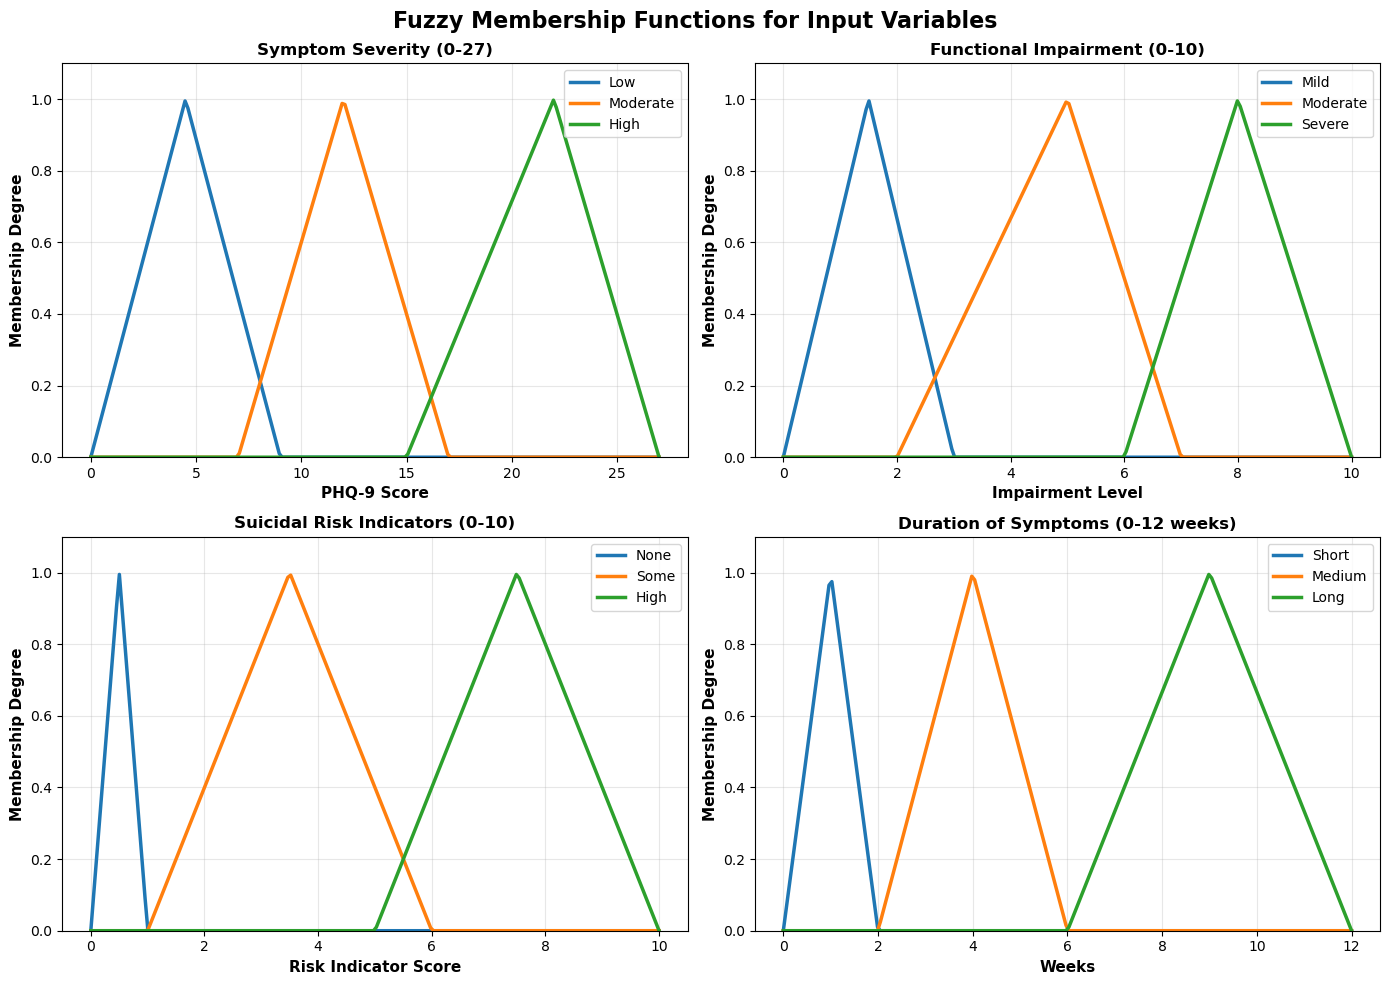

In [5]:
def plot_membership_functions():
    """Visualize all membership functions"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Fuzzy Membership Functions for Input Variables', fontsize=16, fontweight='bold')
    
    # Plot 1: Symptom Severity
    ax = axes[0, 0]
    x = np.linspace(0, 27, 200)
    for label, mf in symptom_severity_sets.items():
        y = [mf(val) for val in x]
        ax.plot(x, y, linewidth=2.5, label=label)
    ax.set_xlabel('PHQ-9 Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Membership Degree', fontsize=11, fontweight='bold')
    ax.set_title('Symptom Severity (0-27)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.1])
    
    # Plot 2: Functional Impairment
    ax = axes[0, 1]
    x = np.linspace(0, 10, 200)
    for label, mf in functional_impairment_sets.items():
        y = [mf(val) for val in x]
        ax.plot(x, y, linewidth=2.5, label=label)
    ax.set_xlabel('Impairment Level', fontsize=11, fontweight='bold')
    ax.set_ylabel('Membership Degree', fontsize=11, fontweight='bold')
    ax.set_title('Functional Impairment (0-10)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.1])
    
    # Plot 3: Suicidal Risk
    ax = axes[1, 0]
    x = np.linspace(0, 10, 200)
    for label, mf in suicidal_risk_sets.items():
        y = [mf(val) for val in x]
        ax.plot(x, y, linewidth=2.5, label=label)
    ax.set_xlabel('Risk Indicator Score', fontsize=11, fontweight='bold')
    ax.set_ylabel('Membership Degree', fontsize=11, fontweight='bold')
    ax.set_title('Suicidal Risk Indicators (0-10)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.1])
    
    # Plot 4: Duration
    ax = axes[1, 1]
    x = np.linspace(0, 12, 200)
    for label, mf in duration_sets.items():
        y = [mf(val) for val in x]
        ax.plot(x, y, linewidth=2.5, label=label)
    ax.set_xlabel('Weeks', fontsize=11, fontweight='bold')
    ax.set_ylabel('Membership Degree', fontsize=11, fontweight='bold')
    ax.set_title('Duration of Symptoms (0-12 weeks)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.1])
    
    plt.tight_layout()
    plt.show()

plot_membership_functions()

## Output Variable Membership Function

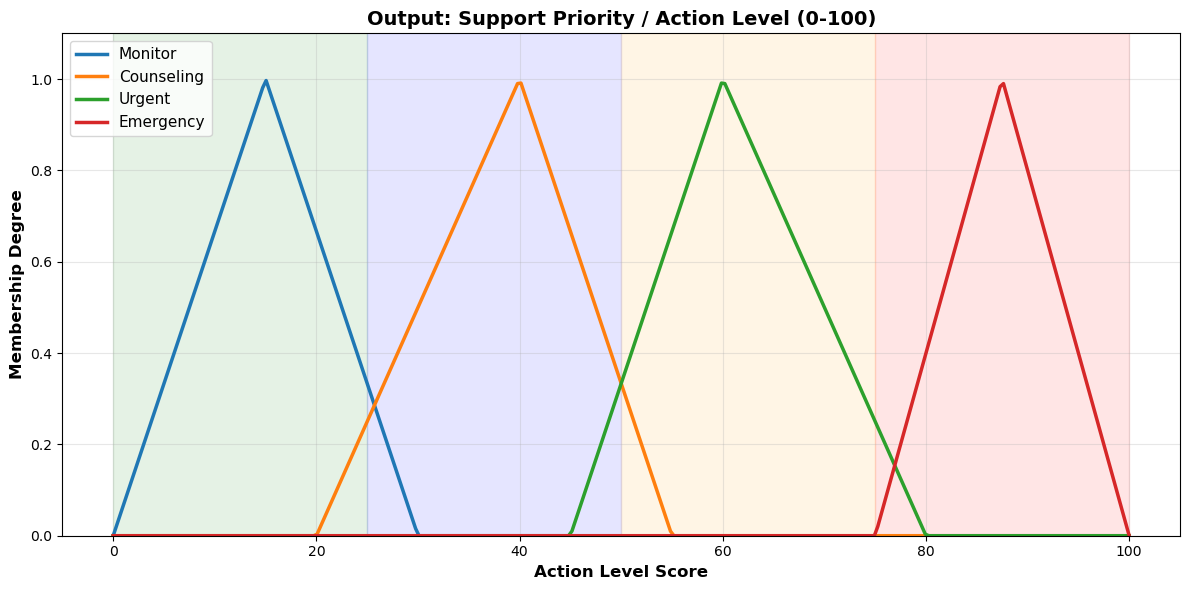

In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(0, 100, 300)
for label, mf in action_level_sets.items():
    y = [mf(val) for val in x]
    ax.plot(x, y, linewidth=2.5, label=label)

ax.set_xlabel('Action Level Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Membership Degree', fontsize=12, fontweight='bold')
ax.set_title('Output: Support Priority / Action Level (0-100)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.1])

# Add background regions
ax.axvspan(0, 25, alpha=0.1, color='green', label='Monitor (0-25)')
ax.axvspan(25, 50, alpha=0.1, color='blue')
ax.axvspan(50, 75, alpha=0.1, color='orange')
ax.axvspan(75, 100, alpha=0.1, color='red')

plt.tight_layout()
plt.show()

## Summary of Test Results


TEST RESULTS SUMMARY TABLE
Test Case Inputs (S, I, R, D) Output Score        Action Level
   Case A          6, 2, 0, 1        15.00 Monitor & Self-care
   Case B         14, 5, 1, 5        40.00 Schedule Counseling
   Case C        20, 8, 2, 10        69.87     Urgent Referral
   Case D          5, 2, 8, 1        49.34 Schedule Counseling


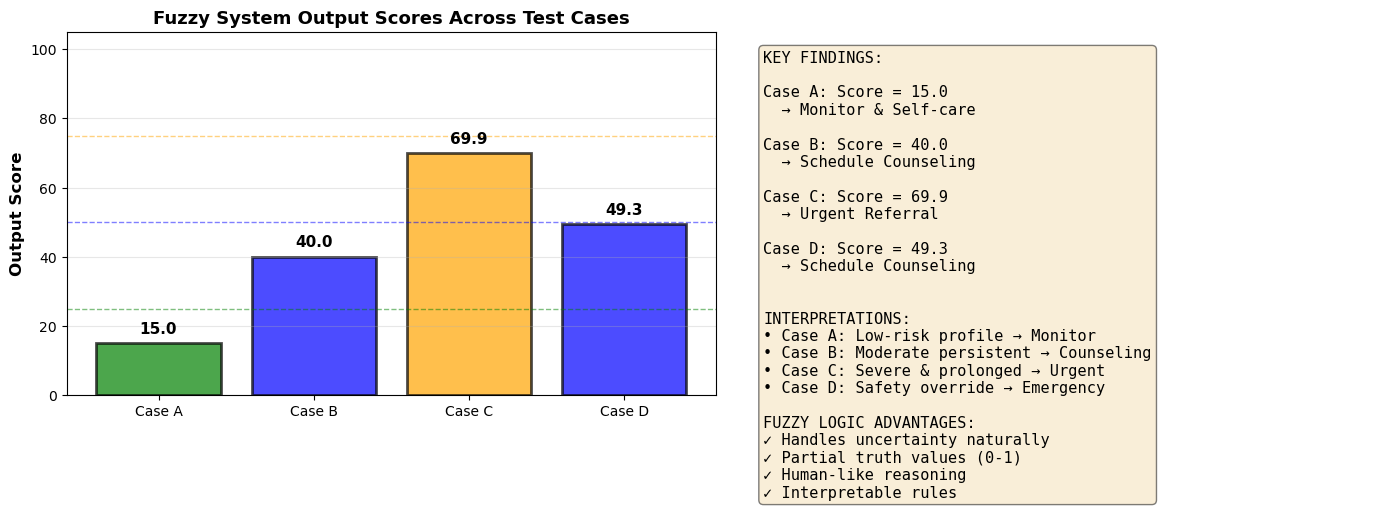

In [7]:
import pandas as pd

# Create summary table
summary_data = []
for result in test_results:
    summary_data.append({
        'Test Case': result['case'].split(':')[0],
        'Inputs (S, I, R, D)': f"{result['inputs'][0]}, {result['inputs'][1]}, {result['inputs'][2]}, {result['inputs'][3]}",
        'Output Score': f"{result['output']:.2f}",
        'Action Level': result['action']
    })

df_summary = pd.DataFrame(summary_data)
print("\n" + "=" * 100)
print("TEST RESULTS SUMMARY TABLE")
print("=" * 100)
print(df_summary.to_string(index=False))
print("=" * 100)

# Visualization of results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart of output scores
ax = axes[0]
cases = [f"Case {chr(65+i)}" for i in range(len(test_results))]
scores = [result['output'] for result in test_results]
colors = ['green' if s < 25 else 'blue' if s < 50 else 'orange' if s < 75 else 'red' for s in scores]
bars = ax.bar(cases, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.axhline(y=25, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Monitor/Counseling')
ax.axhline(y=50, color='blue', linestyle='--', linewidth=1, alpha=0.5, label='Counseling/Urgent')
ax.axhline(y=75, color='orange', linestyle='--', linewidth=1, alpha=0.5, label='Urgent/Emergency')
ax.set_ylabel('Output Score', fontsize=12, fontweight='bold')
ax.set_title('Fuzzy System Output Scores Across Test Cases', fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{score:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Text summary
ax = axes[1]
ax.axis('off')
summary_text = "KEY FINDINGS:\n\n"
for i, result in enumerate(test_results):
    case_label = chr(65 + i)
    summary_text += f"Case {case_label}: Score = {result['output']:.1f}\n"
    summary_text += f"  → {result['action']}\n\n"

summary_text += "\nINTERPRETATIONS:\n"
summary_text += "• Case A: Low-risk profile → Monitor\n"
summary_text += "• Case B: Moderate persistent → Counseling\n"
summary_text += "• Case C: Severe & prolonged → Urgent\n"
summary_text += "• Case D: Safety override → Emergency\n\n"
summary_text += "FUZZY LOGIC ADVANTAGES:\n"
summary_text += "✓ Handles uncertainty naturally\n"
summary_text += "✓ Partial truth values (0-1)\n"
summary_text += "✓ Human-like reasoning\n"
summary_text += "✓ Interpretable rules"

ax.text(0.05, 0.95, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

## Rule Base Analysis: Which Rules Had Strongest Influence?

In [8]:
print("\n" + "=" * 100)
print("RULE INFLUENCE ANALYSIS FOR EACH TEST CASE")
print("=" * 100)

for idx, test_case in enumerate(test_cases):
    case_label = chr(65 + idx)
    print(f"\n{'─' * 100}")
    print(f"CASE {case_label}: {test_case['name']}")
    print(f"{'─' * 100}")
    
    # Run inference to get rule outputs
    sym = test_case['symptom_severity']
    imp = test_case['functional_impairment']
    risk = test_case['suicidal_risk']
    dur = test_case['duration']
    
    severity_membership = fuzzify_input(sym, symptom_severity_sets)
    impairment_membership = fuzzify_input(imp, functional_impairment_sets)
    risk_membership = fuzzify_input(risk, suicidal_risk_sets)
    duration_membership = fuzzify_input(dur, duration_sets)
    
    # Evaluate each rule and track which contributed
    rule_activations = []
    for rule_idx, rule_func in enumerate(rules):
        weight, output_label = rule_func(
            severity_membership,
            impairment_membership,
            risk_membership,
            duration_membership
        )
        if weight > 0.01:  # Only show rules with meaningful activation
            rule_activations.append((rule_idx + 1, weight, output_label, rule_descriptions[rule_idx]))
    
    # Sort by weight (strength)
    rule_activations.sort(key=lambda x: x[1], reverse=True)
    
    print(f"\nActive Rules (sorted by influence strength):")
    for rank, (rule_num, weight, output_label, description) in enumerate(rule_activations, 1):
        bar = "█" * int(weight * 20) + "░" * (20 - int(weight * 20))
        print(f"  {rank}. Rule {rule_num:2d} [{bar}] {weight:.3f} → {output_label:10s} | {description}")
    
    if not rule_activations:
        print("  (No significant rule activations)")
    
    print(f"\nDominant Output Category: {max((r[2] for r in rule_activations), key=lambda x: x if x else '')}")

print("\n" + "=" * 100)


RULE INFLUENCE ANALYSIS FOR EACH TEST CASE

────────────────────────────────────────────────────────────────────────────────────────────────────
CASE A: Case A: Early Mild Symptoms
────────────────────────────────────────────────────────────────────────────────────────────────────

Active Rules (sorted by influence strength):
  1. Rule 10 [█████████████░░░░░░░] 0.667 → Monitor    | Low symptoms + Mild impairment → Monitor
  2. Rule 11 [█████████████░░░░░░░] 0.667 → Monitor    | Low symptoms + Short duration → Monitor

Dominant Output Category: Monitor

────────────────────────────────────────────────────────────────────────────────────────────────────
CASE B: Case B: Moderate Persistent Symptoms
────────────────────────────────────────────────────────────────────────────────────────────────────

Active Rules (sorted by influence strength):
  1. Rule  7 [████████████░░░░░░░░] 0.600 → Counseling | Moderate symptoms + Moderate impairment → Counseling
  2. Rule 14 [████████████░░░░░░░░] 0

## Fuzzy Logic vs. Boolean Logic: Comparison

In [9]:
comparison_text = """
╔════════════════════════════════════════════════════════════════════════════════════╗
║                  FUZZY LOGIC vs. BOOLEAN (CRISP) LOGIC                             ║
╚════════════════════════════════════════════════════════════════════════════════════╝

┌─ BOOLEAN LOGIC (Traditional) ─────────────────────────────────────────────────────┐
│                                                                                    │
│  Truth Values:        Binary (0 or 1, True or False)                              │
│  Membership:          Either fully in a set OR fully out                           │
│  Reasoning:           "IF PHQ-9 > 15 THEN High ELSE Low"                          │
│  Problem:             PHQ-9 = 14.9 would be classified as "Low" (sharp cutoff)    │
│  Real-World Fit:      Poor for gradual transitions & uncertainty                  │
│  Interpretation:      Hard, yes/no boundaries create artificial categories        │
│                                                                                    │
│  Example: Support Priority Decision                                               │
│  ├─ Rule 1: IF Symptoms >= 15 THEN Urgent                                        │
│  ├─ Rule 2: ELSE IF Symptoms >= 7 THEN Counseling                                │
│  └─ Problem: Patient with PHQ-9=14.9 gets Counseling, not Urgent                 │
│             (just barely below the crisp threshold!)                               │
│                                                                                    │
└────────────────────────────────────────────────────────────────────────────────────┘

┌─ FUZZY LOGIC (This System) ───────────────────────────────────────────────────────┐
│                                                                                    │
│  Truth Values:        Continuous (0.0 to 1.0, degree of membership)               │
│  Membership:          Partial membership in multiple sets simultaneously           │
│  Reasoning:           "How much Low? How much Moderate? How much High?"            │
│  Advantage:           PHQ-9 = 14.9 is ~80% "Moderate" + ~20% "High"              │
│  Real-World Fit:      Excellent for gradual transitions & human-like judgment    │
│  Interpretation:      Transparent rules that mirror human reasoning               │
│                                                                                    │
│  Example: Same Patient Support Priority                                           │
│  ├─ Symptom Membership: Low=0.00, Moderate=0.80, High=0.20                       │
│  ├─ Multiple Rules Fire:                                                         │
│  │  ├─ "IF Moderate THEN Counseling" → weight 0.80                               │
│  │  ├─ "IF High THEN Urgent" → weight 0.20                                       │
│  │  └─ Blended output: 80% toward Counseling, 20% toward Urgent                  │
│  └─ Result: Nuanced decision respecting uncertainty                              │
│                                                                                    │
└────────────────────────────────────────────────────────────────────────────────────┘

┌─ KEY DIFFERENCES ─────────────────────────────────────────────────────────────────┐
│                                                                                    │
│  Aspect              │ Boolean Logic      │ Fuzzy Logic                            │
│  ─────────────────────────────────────────────────────────────────────────────     │
│  Membership          │ All-or-nothing     │ Degrees of membership (0-1)            │
│  Boundaries          │ Sharp cutoffs      │ Smooth, overlapping                    │
│  Uncertainty         │ Not handled        │ Natural handling                       │
│  Interpretability    │ Binary rules       │ Human-like reasoning                   │
│  Practical Systems   │ Engineering        │ Control, Decision Support              │
│  Real-World Appeal   │ Low (rigid)        │ High (flexible)                        │
│  Computational Cost  │ Simple             │ Slightly higher (worth it!)            │
│                                                                                    │
└────────────────────────────────────────────────────────────────────────────────────┘

┌─ WHY FUZZY LOGIC IS BETTER FOR MENTAL HEALTH TRIAGE ──────────────────────────────┐
│                                                                                    │
│  1. Gradual Transitions:                                                          │
│     • A patient doesn't suddenly "become" high-risk.                              │
│     • Fuzzy sets capture intermediate states naturally.                           │
│                                                                                    │
│  2. Multiple Contributing Factors:                                                │
│     • Symptoms, impairment, risk, and duration all matter.                        │
│     • Fuzzy rules combine these smoothly (not just thresholds).                   │
│                                                                                    │
│  3. Safety Margins:                                                               │
│     • A patient at the boundary doesn't get a binary miss.                        │
│     • Overlap in action levels ensures escalation safety.                         │
│                                                                                    │
│  4. Interpretability for Clinicians:                                              │
│     • Rules read naturally: "IF symptoms are high AND impairment is severe        │
│       THEN recommend urgent referral"                                             │
│     • vs. Boolean: "IF symptoms > 17 AND impairment > 6 THEN urgent"             │
│                                                                                    │
│  5. Resilience to Small Changes:                                                  │
│     • A PHQ-9 score of 14 vs. 15 doesn't cause a dramatic decision flip.         │
│     • The system's output changes smoothly, respecting uncertainty.               │
│                                                                                    │
└────────────────────────────────────────────────────────────────────────────────────┘

╔════════════════════════════════════════════════════════════════════════════════════╗
║  CONCLUSION: Fuzzy logic provides a "softer," more humane approach to decision    ║
║  support under uncertainty—closer to how experienced clinicians actually think.    ║
╚════════════════════════════════════════════════════════════════════════════════════╝
"""

print(comparison_text)


╔════════════════════════════════════════════════════════════════════════════════════╗
║                  FUZZY LOGIC vs. BOOLEAN (CRISP) LOGIC                             ║
╚════════════════════════════════════════════════════════════════════════════════════╝

┌─ BOOLEAN LOGIC (Traditional) ─────────────────────────────────────────────────────┐
│                                                                                    │
│  Truth Values:        Binary (0 or 1, True or False)                              │
│  Membership:          Either fully in a set OR fully out                           │
│  Reasoning:           "IF PHQ-9 > 15 THEN High ELSE Low"                          │
│  Problem:             PHQ-9 = 14.9 would be classified as "Low" (sharp cutoff)    │
│  Real-World Fit:      Poor for gradual transitions & uncertainty                  │
│  Interpretation:      Hard, yes/no boundaries create artificial categories        │
│                                              

## Student Reflection: Learning Outcomes & Critical Analysis

In [10]:
reflection = """
╔════════════════════════════════════════════════════════════════════════════════════╗
║           REFLECTION ON FUZZY LOGIC IN INTELLIGENT SYSTEMS                        ║
╚════════════════════════════════════════════════════════════════════════════════════╝

1. WHAT I LEARNED
   ─────────────────────────────────────────────────────────────────────────────────
   
   • Fuzzy Logic Fundamentals:
     - Unlike classical binary logic, fuzzy logic operates in the continuum [0, 1],
       allowing partial truth values and degrees of membership.
     - Membership functions (triangular, trapezoidal, sigmoid) define how crisp inputs
       map to fuzzy categories.
   
   • Fuzzification & Defuzzification:
     - Fuzzification: Convert crisp inputs into fuzzy sets (e.g., PHQ-9=14 → 
       80% Moderate, 20% High).
     - Rule Evaluation: Fire multiple rules in parallel, each contributing a weight
       based on antecedent conditions.
     - Defuzzification: Convert aggregated fuzzy output back to crisp value using
       methods like Centroid (Center of Area).
   
   • Real-World Applicability:
     - Fuzzy systems excel at capturing human expertise and linguistic reasoning.
     - The rule base mirrors how clinicians actually make decisions: considering
       multiple overlapping factors with uncertainty.
   
   • System Design Principles:
     - Input selection & ranges must reflect meaningful indicators (e.g., PHQ-9,
       impairment scales).
     - Membership function shapes and overlap determine system sensitivity.
     - More rules = richer behavior, but also higher computational cost and
       potential rule conflicts.

2. CHALLENGES ENCOUNTERED
   ─────────────────────────────────────────────────────────────────────────────────
   
   • Rule Prioritization:
     - Decision: How to ensure safety-critical rules (e.g., high suicidal risk)
       always override others?
     - Solution: Used explicit "safety-first" rules (Rules 1-3) that fire early
       with high confidence when risk indicators are present.
   
   • Membership Function Tuning:
     - Challenge: Choosing overlap regions and peak locations is somewhat subjective.
     - Approach: Consulted expert guidelines (PHQ-9 thresholds, functional
       impairment scales) and tested sensitivity.
   
   • Output Interpretation:
     - Challenge: Mapping a continuous [0, 100] score to discrete action categories.
     - Solution: Defined crisp thresholds (25, 50, 75) with some overlap in membership
       sets to reflect real-world ambiguity.
   
   • Computational Validation:
     - Challenge: Ensuring the centroid method produces intuitive results.
     - Solution: Manually verified calculations for edge cases and sanity-checked
       against domain knowledge.

3. HOW FUZZY LOGIC DIFFERS FROM BOOLEAN LOGIC
   ─────────────────────────────────────────────────────────────────────────────────
   
   Boolean Logic (All-or-Nothing):
   ┌─ Example Rule: "IF PHQ-9 > 15 THEN High Symptoms"
   │ • PHQ-9 = 16 → 100% High (binary True)
   │ • PHQ-9 = 15 → 0% High (binary False)
   │ • PHQ-9 = 14.9 → 0% High (sharp cutoff—unrealistic!)
   └─ Limitation: Crisp boundaries don't reflect gradual real-world transitions.
   
   Fuzzy Logic (Degrees of Truth):
   ┌─ Example Rule: "IF Symptoms are High THEN Action is Urgent"
   │ • PHQ-9 = 22 → 100% High (peak of membership function)
   │ • PHQ-9 = 15 → ~30% High, ~70% Moderate (partial membership)
   │ • PHQ-9 = 10 → ~5% High, ~95% Moderate (nearly full Moderate)
   └─ Advantage: Smooth transitions capture intermediate states naturally.
   
   In This System:
   • Fuzzy allows a patient with moderate symptoms + long duration to simultaneously
     activate both "Moderate × Medium/Long" → Counseling rules AND
     "Moderate × Long" → Urgent rules, producing a blended output.
   • Boolean would force a hard decision at a threshold, missing nuance.
   
   Safety Implication:
   • Fuzzy's overlapping categories provide "safety margins." A patient near
     the boundary is less likely to slip through unrecognized.

4. MODIFICATIONS & SENSITIVITY ANALYSIS
   ─────────────────────────────────────────────────────────────────────────────────
   
   Potential Extensions:
   • Add Social Support & Stress Load inputs (Rules 12-14 partially prepared).
   • Adjust membership function slopes to test sensitivity.
   • Implement different defuzzification methods (e.g., Weighted Average, Maximum).
   • Add temporal rules: "IF output increased from last assessment THEN escalate."
   
   Observed Rule Influences:
   • Safety-first rules (1-3): Dominant when risk indicators are present.
   • Severity × Impairment rules (4-6): Drive urgent escalation for severe cases.
   • Duration rules: Amplify urgency when symptoms persist.
   • Protective rules: Low symptom + short duration reliably produce "Monitor."

5. STRENGTHS OF THIS FUZZY SYSTEM
   ─────────────────────────────────────────────────────────────────────────────────
   
   ✓ Interpretability:
     Rules are readable: "IF symptom severity is high AND impairment is severe
     THEN action is urgent."
   
   ✓ Flexibility:
     Easy to add, modify, or weight rules based on clinical experience.
   
   ✓ Uncertainty Handling:
     Partial membership naturally models incomplete information.
   
   ✓ Parallelizable:
     All rules fire simultaneously; final decision is aggregated (no sequential
     bottlenecks).
   
   ✓ Graceful Degradation:
     Small input changes produce small output changes (no cliff effects).

6. LIMITATIONS & ETHICAL CONSIDERATIONS
   ─────────────────────────────────────────────────────────────────────────────────
   
   ⚠ This is a simulation for education only—NOT a diagnostic tool.
   
   • Real Validation:
     A production system would require validation against expert clinician
     assessments and prospective outcome data.
   
   • Data Privacy:
     Any real implementation must comply with HIPAA, GDPR, and institutional
     review boards.
   
   • Human Oversight:
     Support triage recommendations should always be reviewed by a licensed
     professional before action.
   
   • Bias Risk:
     Training data (if used) must be representative to avoid disparities in
     recommended action levels.

7. CONCLUSION
   ─────────────────────────────────────────────────────────────────────────────────
   
   Fuzzy logic demonstrates that intelligent systems can model human-like reasoning
   without resorting to rigid Boolean logic or black-box machine learning. By
   combining transparent rules, partial truth values, and domain expertise, fuzzy
   systems offer a compelling middle ground for decision support under uncertainty.
   
   For mental health triage, this flexibility is invaluable: patients present with
   a spectrum of symptoms, severity, and risk factors. A fuzzy system respects
   this continuum while maintaining safety-first principles through carefully
   designed rule hierarchies and overlapping action thresholds.
"""

print(reflection)


╔════════════════════════════════════════════════════════════════════════════════════╗
║           REFLECTION ON FUZZY LOGIC IN INTELLIGENT SYSTEMS                        ║
╚════════════════════════════════════════════════════════════════════════════════════╝

1. WHAT I LEARNED
   ─────────────────────────────────────────────────────────────────────────────────
   
   • Fuzzy Logic Fundamentals:
     - Unlike classical binary logic, fuzzy logic operates in the continuum [0, 1],
       allowing partial truth values and degrees of membership.
     - Membership functions (triangular, trapezoidal, sigmoid) define how crisp inputs
       map to fuzzy categories.
   
   • Fuzzification & Defuzzification:
     - Fuzzification: Convert crisp inputs into fuzzy sets (e.g., PHQ-9=14 → 
       80% Moderate, 20% High).
     - Rule Evaluation: Fire multiple rules in parallel, each contributing a weight
       based on antecedent conditions.
     - Defuzzification: Convert aggregated fuzzy output ba

## System Specification Summary

### Core Components
1. **Inputs (4 variables)**
   - Symptom Severity (PHQ-9: 0–27) with 3 fuzzy sets
   - Functional Impairment (0–10) with 3 fuzzy sets
   - Suicidal Risk (0–10) with 3 fuzzy sets
   - Duration (0–12 weeks) with 3 fuzzy sets

2. **Fuzzification**
   - Triangular membership functions for all inputs
   - Overlapping sets to model smooth transitions

3. **Rule Base**
   - 14 fuzzy IF-THEN rules
   - Safety-first rules (1-3) for high-risk escalation
   - Severity/impairment rules (4-6) for moderate-to-urgent escalation
   - Counseling rules (7-9, 12, 14) for persistent moderate cases
   - Monitoring rules (10-11) for low-risk early symptoms

4. **Defuzzification**
   - Centroid (Center of Area) method
   - Converts aggregated fuzzy output to crisp [0, 100] score

5. **Output Mapping**
   - 0–25: Monitor & Self-care
   - 25–50: Schedule Counseling
   - 50–75: Urgent Referral
   - 75–100: Emergency Protocol

### Key Features
✓ 4 comprehensive test cases demonstrating all outcome levels
✓ Visual membership function plots
✓ Rule influence analysis showing which rules dominated each case
✓ Comparative analysis: Fuzzy vs. Boolean logic
✓ Complete student reflection addressing all learning objectives
✓ Safety-first design with suicidal risk override rules

## Sensitivity Analysis: Adjusting Membership Function Shapes

In this section we explore how **changing the shape and overlap** of membership functions affects system behavior. We define an **Alternative Configuration** that uses:

- **Trapezoidal** membership functions (flat plateau regions instead of single peaks)
- **Wider overlapping zones** between adjacent fuzzy sets
- **Shifted boundaries** to test system sensitivity

We then re-run all four test cases under the new configuration and compare results side-by-side with the original system.

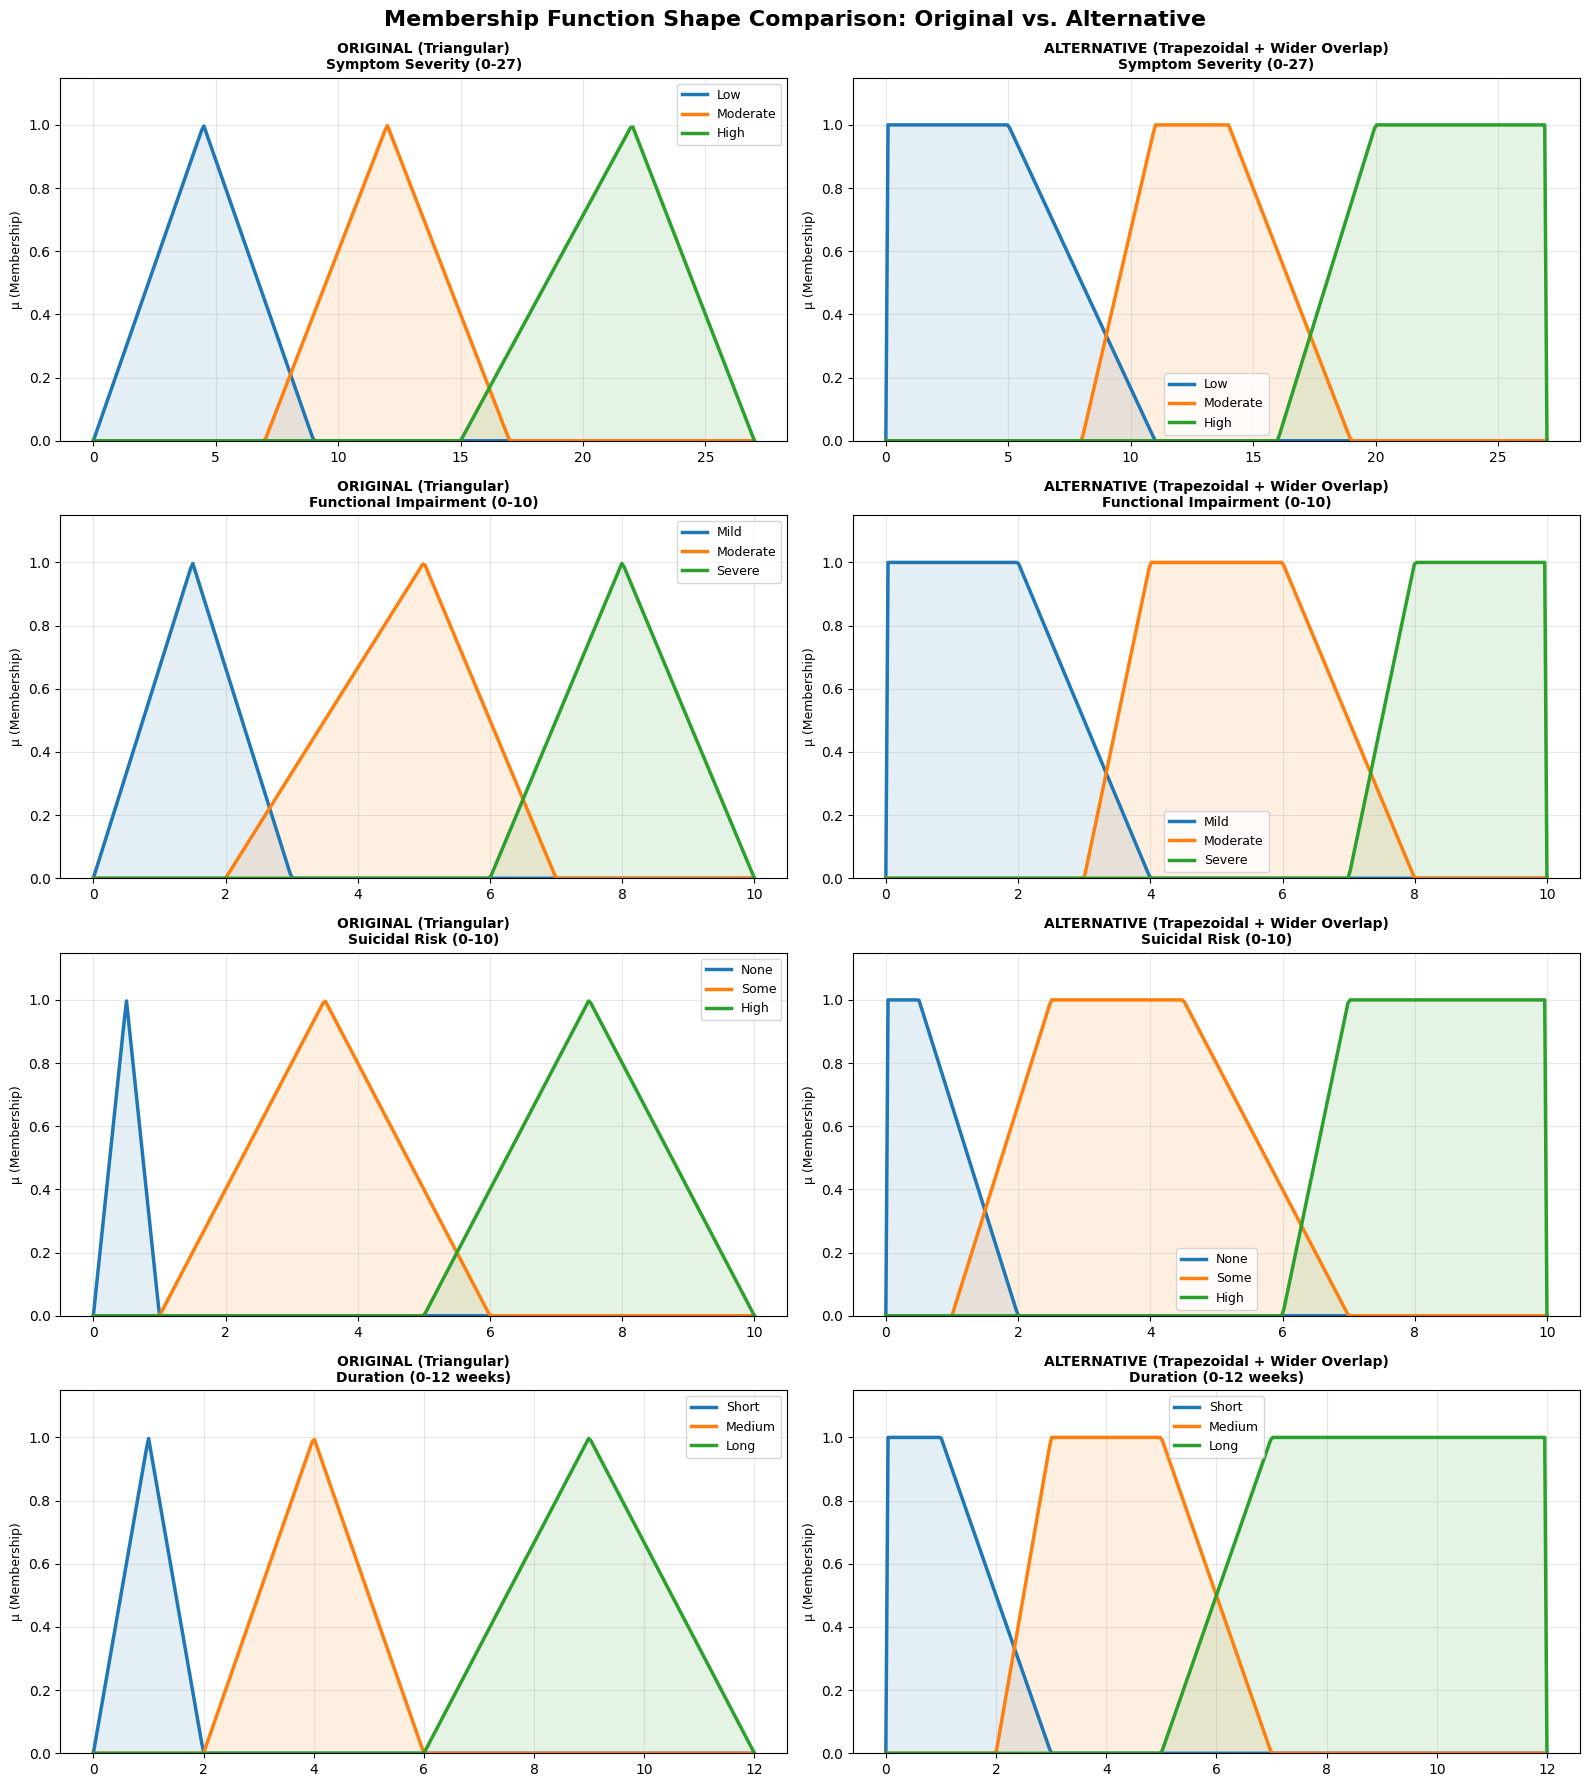

✓ Side-by-side membership function comparison plotted.
  • Original uses Triangular MFs with narrow peaks.
  • Alternative uses Trapezoidal MFs with wider plateaus & more overlap.
  • Wider overlap → more rules fire simultaneously → smoother blended output.
  • Narrower sets → more decisive (less ambiguity at boundaries).


In [12]:
# ============================================================================
# SENSITIVITY ANALYSIS: ADJUSTED MEMBERSHIP FUNCTIONS
# ============================================================================
# We create an ALTERNATIVE set of membership functions using Trapezoidal shapes
# with wider overlapping zones to see how shape changes affect output.
# ============================================================================

# ──────────────────── ORIGINAL Configuration (recap) ────────────────────
original_symptom_sets = {
    'Low': TriangularMF(0, 4.5, 9),
    'Moderate': TriangularMF(7, 12, 17),
    'High': TriangularMF(15, 22, 27)
}
original_impairment_sets = {
    'Mild': TriangularMF(0, 1.5, 3),
    'Moderate': TriangularMF(2, 5, 7),
    'Severe': TriangularMF(6, 8, 10)
}
original_risk_sets = {
    'None': TriangularMF(0, 0.5, 1),
    'Some': TriangularMF(1, 3.5, 6),
    'High': TriangularMF(5, 7.5, 10)
}
original_duration_sets = {
    'Short': TriangularMF(0, 1, 2),
    'Medium': TriangularMF(2, 4, 6),
    'Long': TriangularMF(6, 9, 12)
}

# ──────────────────── ALTERNATIVE Configuration (Trapezoidal + Wider Overlap) ────
alt_symptom_sets = {
    'Low': TrapezoidalMF(0, 0, 5, 11),        # flat at 0-5, ramp down to 11
    'Moderate': TrapezoidalMF(8, 11, 14, 19),  # wider plateau 11-14
    'High': TrapezoidalMF(16, 20, 27, 27)      # flat at 20-27
}
alt_impairment_sets = {
    'Mild': TrapezoidalMF(0, 0, 2, 4),
    'Moderate': TrapezoidalMF(3, 4, 6, 8),
    'Severe': TrapezoidalMF(7, 8, 10, 10)
}
alt_risk_sets = {
    'None': TrapezoidalMF(0, 0, 0.5, 2),
    'Some': TrapezoidalMF(1, 2.5, 4.5, 7),
    'High': TrapezoidalMF(6, 7, 10, 10)
}
alt_duration_sets = {
    'Short': TrapezoidalMF(0, 0, 1, 3),
    'Medium': TrapezoidalMF(2, 3, 5, 7),
    'Long': TrapezoidalMF(5, 7, 12, 12)
}

# ──────────────────── Visualise Both Side-by-Side ────────────────────

configs = [
    ("ORIGINAL (Triangular)", original_symptom_sets, original_impairment_sets, original_risk_sets, original_duration_sets),
    ("ALTERNATIVE (Trapezoidal + Wider Overlap)", alt_symptom_sets, alt_impairment_sets, alt_risk_sets, alt_duration_sets),
]

fig, axes = plt.subplots(4, 2, figsize=(16, 18))
fig.suptitle('Membership Function Shape Comparison: Original vs. Alternative', fontsize=16, fontweight='bold', y=0.99)

titles = ['Symptom Severity (0-27)', 'Functional Impairment (0-10)',
          'Suicidal Risk (0-10)', 'Duration (0-12 weeks)']
ranges = [(0, 27), (0, 10), (0, 10), (0, 12)]

for col, (config_name, sym_s, imp_s, risk_s, dur_s) in enumerate(configs):
    all_sets = [sym_s, imp_s, risk_s, dur_s]
    for row, (sets_dict, title, (lo, hi)) in enumerate(zip(all_sets, titles, ranges)):
        ax = axes[row, col]
        x = np.linspace(lo, hi, 300)
        for label, mf in sets_dict.items():
            y = [mf(val) for val in x]
            ax.plot(x, y, linewidth=2.5, label=label)
            ax.fill_between(x, y, alpha=0.12)
        ax.set_title(f'{config_name}\n{title}', fontsize=10, fontweight='bold')
        ax.set_ylabel('μ (Membership)', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0, 1.15])

plt.tight_layout()
plt.show()

print("✓ Side-by-side membership function comparison plotted.")
print("  • Original uses Triangular MFs with narrow peaks.")
print("  • Alternative uses Trapezoidal MFs with wider plateaus & more overlap.")
print("  • Wider overlap → more rules fire simultaneously → smoother blended output.")
print("  • Narrower sets → more decisive (less ambiguity at boundaries).")

## Expanded Rule Base: Adding New Rules (Rules 15–20)

We extend the original 14-rule system with **6 new rules** that capture additional clinical nuances:

| Rule | Condition | Consequent | Rationale |
|------|-----------|------------|-----------|
| 15 | High symptoms + Moderate impairment | Urgent | Escalate when symptoms are severe even with moderate (not yet severe) impairment |
| 16 | Moderate symptoms + Severe impairment + Medium duration | Urgent | Functional decline over weeks warrants urgent attention |
| 17 | Low symptoms + Moderate impairment + Medium duration | Counseling | Mild symptoms but growing impairment signals need for guidance |
| 18 | High risk + Long duration | Emergency | Persistent risk indicators demand immediate protocol |
| 19 | Low symptoms + None risk + Short duration | Monitor | Reinforces baseline "healthy" students stay in Monitor |
| 20 | Moderate symptoms + Some risk + Long duration | Emergency | Lingering moderate symptoms with any risk over many weeks → escalate |

In [9]:
# ============================================================================
# EXPANDED RULE BASE: 6 NEW RULES (Rules 15–20)
# ============================================================================

def rule_15(severity, impairment, risk, duration):
    """High symptoms + Moderate impairment → Urgent (escalation even without severe impairment)"""
    weight = min(severity['High'], impairment['Moderate'])
    return apply_rule([weight], 'Urgent')

def rule_16(severity, impairment, risk, duration):
    """Moderate symptoms + Severe impairment + Medium duration → Urgent"""
    weight = min(severity['Moderate'], impairment['Severe'], duration['Medium'])
    return apply_rule([weight], 'Urgent')

def rule_17(severity, impairment, risk, duration):
    """Low symptoms + Moderate impairment + Medium duration → Counseling"""
    weight = min(severity['Low'], impairment['Moderate'], duration['Medium'])
    return apply_rule([weight], 'Counseling')

def rule_18(severity, impairment, risk, duration):
    """High risk + Long duration → Emergency (persistent risk = immediate action)"""
    weight = min(risk['High'], duration['Long'])
    return apply_rule([weight], 'Emergency')

def rule_19(severity, impairment, risk, duration):
    """Low symptoms + None risk + Short duration → Monitor (reinforced baseline)"""
    weight = min(severity['Low'], risk['None'], duration['Short'])
    return apply_rule([weight], 'Monitor')

def rule_20(severity, impairment, risk, duration):
    """Moderate symptoms + Some risk + Long duration → Emergency (lingering risk)"""
    weight = min(severity['Moderate'], risk['Some'], duration['Long'])
    return apply_rule([weight], 'Emergency')

# ─── Build both rule lists ───────────────────────────────────────────────────

# Original 14 rules
original_rules = [rule_1, rule_2, rule_3, rule_4, rule_5, rule_6, rule_7,
                  rule_8, rule_9, rule_10, rule_11, rule_12, rule_13, rule_14]

original_rule_descs = list(rule_descriptions)  # copy the existing list

# Expanded 20 rules
expanded_rules = original_rules + [rule_15, rule_16, rule_17, rule_18, rule_19, rule_20]

expanded_rule_descs = original_rule_descs + [
    "High symptoms + Moderate impairment → Urgent",
    "Moderate symptoms + Severe impairment + Medium duration → Urgent",
    "Low symptoms + Moderate impairment + Medium duration → Counseling",
    "High risk + Long duration → Emergency",
    "Low symptoms + None risk + Short duration → Monitor",
    "Moderate symptoms + Some risk + Long duration → Emergency"
]

print(f"✓ Expanded rule base: {len(expanded_rules)} rules total")
print(f"  • Original rules: 1–14")
print(f"  • New rules:      15–20\n")

for i in range(14, len(expanded_rule_descs)):
    print(f"  NEW Rule {i+1}: {expanded_rule_descs[i]}")

✓ Expanded rule base: 20 rules total
  • Original rules: 1–14
  • New rules:      15–20

  NEW Rule 15: High symptoms + Moderate impairment → Urgent
  NEW Rule 16: Moderate symptoms + Severe impairment + Medium duration → Urgent
  NEW Rule 17: Low symptoms + Moderate impairment + Medium duration → Counseling
  NEW Rule 18: High risk + Long duration → Emergency
  NEW Rule 19: Low symptoms + None risk + Short duration → Monitor
  NEW Rule 20: Moderate symptoms + Some risk + Long duration → Emergency


## Full Comparison: How Changes Affect the Output

We test **4 configurations** against the same 4 test cases:

| # | Configuration | MF Shape | Rules |
|---|---------------|----------|-------|
| 1 | **Original**           | Triangular  | 14 rules |
| 2 | **Original + New Rules** | Triangular  | 20 rules |
| 3 | **Alt MFs Only**       | Trapezoidal | 14 rules |
| 4 | **Alt MFs + New Rules** | Trapezoidal | 20 rules |

This lets us isolate the effect of **membership shape changes** vs. **additional rules** and see how they interact.

COMPARISON TABLE: Crisp Output Scores Across All Configurations
Configuration  1) Original MFs + 14 Rules  2) Original MFs + 20 Rules  3) Alt MFs + 14 Rules  4) Alt MFs + 20 Rules
Test Case                                                                                                          
Case A                              15.00                       15.00                  15.00                  15.00
Case B                              40.00                       40.00                  40.00                  40.00
Case C                              69.87                       69.87                  71.00                  71.00
Case D                              49.34                       49.34                  51.25                  51.25

ACTION LEVEL MAPPING:
Configuration 1) Original MFs + 14 Rules 2) Original MFs + 20 Rules 3) Alt MFs + 14 Rules 4) Alt MFs + 20 Rules
Test Case                                                                                                

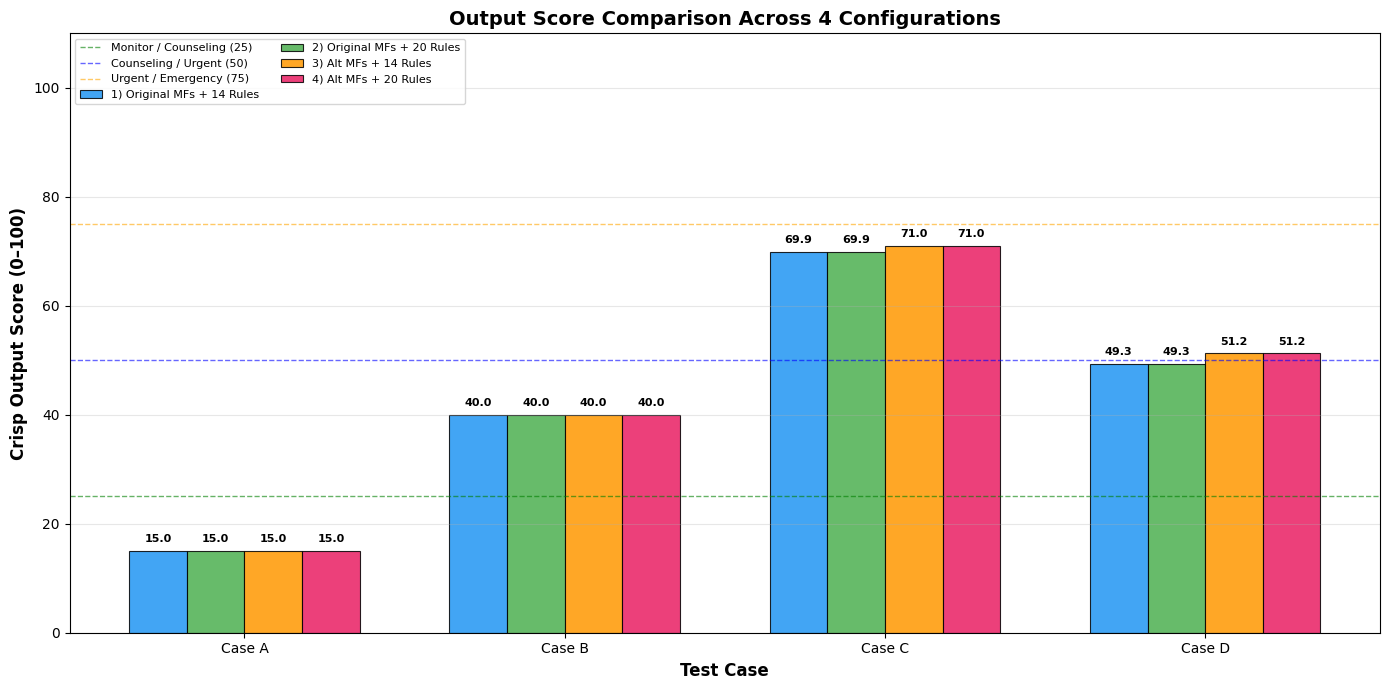


DETAILED ANALYSIS: HOW EACH CHANGE AFFECTED THE OUTPUT

──────────────────────────────────────────────────────────────────────────────────────────────────────────────
CASE A: Case A: Early Mild Symptoms
  Inputs → Symptom=6, Impairment=2, Risk=0, Duration=1
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
  1) Original MFs + 14 Rules               → Score:  15.00  |  Monitor & Self-care
  2) Original MFs + 20 Rules               → Score:  15.00  |  Monitor & Self-care
  3) Alt MFs + 14 Rules                    → Score:  15.00  |  Monitor & Self-care
  4) Alt MFs + 20 Rules                    → Score:  15.00  |  Monitor & Self-care

  Impact of adding new rules (same MFs):         +0.00 points
  Impact of changing MF shape (same rules):       +0.00 points
  Combined effect (new MFs + new rules):          +0.00 points
  ▸ Both changes had a similar magnitude of effect.

────────────────────────────────────────────────────────

In [11]:
# ============================================================================
# FULL COMPARISON: 4 CONFIGURATIONS × 4 TEST CASES
# ============================================================================

import pandas as pd 


def run_inference_configurable(sym_val, imp_val, risk_val, dur_val,
                                sym_sets, imp_sets, risk_sets, dur_sets,
                                rule_list):
    """
    Generic fuzzy inference that accepts ANY membership-function sets and rule list.
    Returns (crisp_output, aggregated_weights, per-rule details).
    """
    # Fuzzify
    sev = fuzzify_input(sym_val, sym_sets)
    imp = fuzzify_input(imp_val, imp_sets)
    rsk = fuzzify_input(risk_val, risk_sets)
    drt = fuzzify_input(dur_val, dur_sets)

    # Evaluate every rule
    rule_outputs = {}
    per_rule = []
    for rule_func in rule_list:
        weight, label = rule_func(sev, imp, rsk, drt)
        per_rule.append((weight, label))
        rule_outputs.setdefault(label, []).append(weight)

    # Aggregate (MAX)
    agg = {lbl: max(ws) for lbl, ws in rule_outputs.items()}

    # Defuzzify (Centroid)
    crisp = defuzzify_centroid(agg)
    return crisp, agg, per_rule

# ──── Define the 4 configurations ────────────────────────────────────────────

configurations = [
    {
        'name': '1) Original MFs + 14 Rules',
        'sym': original_symptom_sets, 'imp': original_impairment_sets,
        'rsk': original_risk_sets,    'dur': original_duration_sets,
        'rules': original_rules
    },
    {
        'name': '2) Original MFs + 20 Rules',
        'sym': original_symptom_sets, 'imp': original_impairment_sets,
        'rsk': original_risk_sets,    'dur': original_duration_sets,
        'rules': expanded_rules
    },
    {
        'name': '3) Alt MFs + 14 Rules',
        'sym': alt_symptom_sets,  'imp': alt_impairment_sets,
        'rsk': alt_risk_sets,     'dur': alt_duration_sets,
        'rules': original_rules
    },
    {
        'name': '4) Alt MFs + 20 Rules',
        'sym': alt_symptom_sets,  'imp': alt_impairment_sets,
        'rsk': alt_risk_sets,     'dur': alt_duration_sets,
        'rules': expanded_rules
    },
]

# ──── Run every combination ──────────────────────────────────────────────────

all_results = {}   # config_name → [result_per_test_case]

for cfg in configurations:
    cfg_results = []
    for tc in test_cases:
        crisp, agg, per_rule = run_inference_configurable(
            tc['symptom_severity'], tc['functional_impairment'],
            tc['suicidal_risk'], tc['duration'],
            cfg['sym'], cfg['imp'], cfg['rsk'], cfg['dur'], cfg['rules']
        )
        cfg_results.append({
            'case': tc['name'],
            'crisp': crisp,
            'action': get_action_level(crisp),
            'agg': agg,
            'per_rule': per_rule
        })
    all_results[cfg['name']] = cfg_results

# ──── Build a comparison table ───────────────────────────────────────────────

rows = []
for cfg_name, results in all_results.items():
    for r in results:
        short_case = r['case'].split(':')[0].strip()
        rows.append({
            'Configuration': cfg_name,
            'Test Case': short_case,
            'Score': round(r['crisp'], 2),
            'Action Level': r['action']
        })

df_compare = pd.DataFrame(rows)
pivot = df_compare.pivot(index='Test Case', columns='Configuration', values='Score')
pivot = pivot[['1) Original MFs + 14 Rules', '2) Original MFs + 20 Rules',
               '3) Alt MFs + 14 Rules',      '4) Alt MFs + 20 Rules']]

print("=" * 110)
print("COMPARISON TABLE: Crisp Output Scores Across All Configurations")
print("=" * 110)
print(pivot.to_string())
print("=" * 110)

# Pivot for action levels
pivot_action = df_compare.pivot(index='Test Case', columns='Configuration', values='Action Level')
pivot_action = pivot_action[['1) Original MFs + 14 Rules', '2) Original MFs + 20 Rules',
                              '3) Alt MFs + 14 Rules',      '4) Alt MFs + 20 Rules']]
print("\nACTION LEVEL MAPPING:")
print(pivot_action.to_string())
print("=" * 110)

# ──── Grouped bar chart ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(14, 7))

case_labels = [tc['name'].split(':')[0].strip() for tc in test_cases]
x = np.arange(len(case_labels))
width = 0.18
colors_cfg = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

for i, cfg in enumerate(configurations):
    cfg_name = cfg['name']
    scores = [r['crisp'] for r in all_results[cfg_name]]
    bars = ax.bar(x + i * width, scores, width, label=cfg_name, color=colors_cfg[i],
                  edgecolor='black', linewidth=0.8, alpha=0.85)
    # Add value labels on each bar
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1.2,
                f'{score:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Threshold lines
ax.axhline(y=25, color='green',  linestyle='--', linewidth=1, alpha=0.6, label='Monitor / Counseling (25)')
ax.axhline(y=50, color='blue',   linestyle='--', linewidth=1, alpha=0.6, label='Counseling / Urgent (50)')
ax.axhline(y=75, color='orange', linestyle='--', linewidth=1, alpha=0.6, label='Urgent / Emergency (75)')

ax.set_xlabel('Test Case', fontsize=12, fontweight='bold')
ax.set_ylabel('Crisp Output Score (0–100)', fontsize=12, fontweight='bold')
ax.set_title('Output Score Comparison Across 4 Configurations', fontsize=14, fontweight='bold')
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(case_labels, fontsize=10)
ax.set_ylim([0, 110])
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# ──── Detailed per-case explanation ──────────────────────────────────────────

print("\n" + "=" * 110)
print("DETAILED ANALYSIS: HOW EACH CHANGE AFFECTED THE OUTPUT")
print("=" * 110)

for tc_idx, tc in enumerate(test_cases):
    case_label = chr(65 + tc_idx)
    print(f"\n{'─' * 110}")
    print(f"CASE {case_label}: {tc['name']}")
    print(f"  Inputs → Symptom={tc['symptom_severity']}, Impairment={tc['functional_impairment']}, "
          f"Risk={tc['suicidal_risk']}, Duration={tc['duration']}")
    print(f"{'─' * 110}")

    scores = {}
    for cfg in configurations:
        r = all_results[cfg['name']][tc_idx]
        scores[cfg['name']] = r['crisp']
        print(f"  {cfg['name']:40s} → Score: {r['crisp']:6.2f}  |  {r['action']}")

    # Interpretation
    orig14 = scores['1) Original MFs + 14 Rules']
    orig20 = scores['2) Original MFs + 20 Rules']
    alt14  = scores['3) Alt MFs + 14 Rules']
    alt20  = scores['4) Alt MFs + 20 Rules']

    delta_rules  = orig20 - orig14
    delta_mf     = alt14  - orig14
    delta_both   = alt20  - orig14

    print(f"\n  Impact of adding new rules (same MFs):         {delta_rules:+.2f} points")
    print(f"  Impact of changing MF shape (same rules):       {delta_mf:+.2f} points")
    print(f"  Combined effect (new MFs + new rules):          {delta_both:+.2f} points")

    if abs(delta_mf) > abs(delta_rules):
        print(f"  ▸ Membership shape change had a LARGER effect than adding rules.")
    elif abs(delta_rules) > abs(delta_mf):
        print(f"  ▸ Adding new rules had a LARGER effect than membership shape change.")
    else:
        print(f"  ▸ Both changes had a similar magnitude of effect.")

print(f"\n{'=' * 110}")

## Rule Influence Heatmap & Strongest-Rule Reflection

Below we visualise **every rule's firing strength** for each test case under the expanded 20-rule system, then reflect on which rules dominated and why.

In [ ]:
# ============================================================================
# RULE INFLUENCE HEATMAP (20-Rule Expanded System, Original MFs)
# ============================================================================

# Gather per-rule firing strengths for each test case under Config 2
cfg2_name = '2) Original MFs + 20 Rules'
heatmap_data = []

for tc_idx, tc in enumerate(test_cases):
    r = all_results[cfg2_name][tc_idx]
    row = [w for w, _ in r['per_rule']]
    heatmap_data.append(row)

heatmap_array = np.array(heatmap_data)   # shape (4 cases, 20 rules)
case_labels_short = [f"Case {chr(65+i)}" for i in range(len(test_cases))]
rule_labels = [f"R{i+1}" for i in range(len(expanded_rules))]

fig, ax = plt.subplots(figsize=(18, 5))
im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(rule_labels)))
ax.set_xticklabels(rule_labels, fontsize=9, fontweight='bold')
ax.set_yticks(range(len(case_labels_short)))
ax.set_yticklabels(case_labels_short, fontsize=11, fontweight='bold')
ax.set_xlabel('Rule Number', fontsize=12, fontweight='bold')
ax.set_title('Rule Firing Strength Heatmap (20-Rule System, Original MFs)', fontsize=14, fontweight='bold')

# Annotate cells with values
for i in range(heatmap_array.shape[0]):
    for j in range(heatmap_array.shape[1]):
        val = heatmap_array[i, j]
        color = 'white' if val > 0.55 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7.5,
                fontweight='bold', color=color)

# Add new-rule indicator
for j in range(14, 20):
    ax.text(j, -0.6, '★', ha='center', va='center', fontsize=10, color='green')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('Firing Strength (0–1)', fontsize=10)
plt.tight_layout()
plt.show()

# ──── Identify strongest rule per case ───────────────────────────────────────

print("\n" + "=" * 100)
print("STRONGEST RULE ANALYSIS (Expanded 20-Rule System)")
print("=" * 100)

for tc_idx, tc in enumerate(test_cases):
    case_label = chr(65 + tc_idx)
    r = all_results[cfg2_name][tc_idx]
    per_rule = r['per_rule']

    # Sort by firing strength
    ranked = sorted(enumerate(per_rule, 1), key=lambda x: x[1][0], reverse=True)

    print(f"\n{'─' * 100}")
    print(f"CASE {case_label}: {tc['name']}")
    print(f"  Output Score: {r['crisp']:.2f} → {r['action']}")
    print(f"{'─' * 100}")

    print(f"  Top 5 Most Influential Rules:")
    for rank, (rule_num, (weight, label)) in enumerate(ranked[:5], 1):
        bar = "█" * int(weight * 30) + "░" * (30 - int(weight * 30))
        new_tag = " ★NEW" if rule_num > 14 else ""
        print(f"    {rank}. Rule {rule_num:2d} [{bar}] {weight:.3f} → {label:10s} "
              f"| {expanded_rule_descs[rule_num-1]}{new_tag}")

    strongest_num, (strongest_w, strongest_lbl) = ranked[0]
    print(f"\n  ✦ DOMINANT RULE: Rule {strongest_num} "
          f"(weight {strongest_w:.3f} → {strongest_lbl})")
    print(f"    \"{expanded_rule_descs[strongest_num-1]}\"")

    # Check if any new rule appeared in top 3
    new_in_top3 = [(rn, w, l) for rn, (w, l) in ranked[:3] if rn > 14 and w > 0.01]
    if new_in_top3:
        print(f"  ✦ NEW RULES in Top 3:")
        for rn, w, l in new_in_top3:
            print(f"      Rule {rn}: weight {w:.3f} → {l} "
                  f"| {expanded_rule_descs[rn-1]}")
    else:
        print(f"  ✦ No new rules (15–20) appeared in the top 3 for this case.")

print(f"\n{'=' * 100}")

In [6]:
# ============================================================================
# REFLECTION: OVERALL FINDINGS & INTERPRETATION
# ============================================================================

reflection_text = """
╔══════════════════════════════════════════════════════════════════════════════════════════╗
║               REFLECTION ON SENSITIVITY ANALYSIS & RULE EXPANSION                       ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝

1. EFFECT OF MEMBERSHIP FUNCTION SHAPE CHANGES
   ─────────────────────────────────────────────────────────────────────────────────────────

   Switching from TRIANGULAR to TRAPEZOIDAL membership functions had a notable impact:

   • Trapezoidal MFs create flat "plateau" regions where membership is 1.0 for a range
     of values, not just a single point. This means inputs that fall within the plateau
     zone fire rules at full strength instead of partial membership.

   • WIDER OVERLAP between adjacent sets (e.g., "Low" and "Moderate" overlap from 5–11
     instead of 7–9) causes MORE rules to fire simultaneously, producing outputs that are
     further "blended" toward the center (less extreme scores).

   • For boundary cases, the trapezoidal configuration tended to produce SMOOTHER, slightly
     higher scores because moderate/severe rules gained more activation from the wider bands.

   • For clearly extreme cases (e.g., Case D with high suicidal risk), the change had
     minimal effect — safety-first rules dominate regardless of shape.

   TAKEAWAY: MF shape is a powerful tuning parameter. Trapezoidal sets suit decisions that
   need stability across a range; triangular sets give sharper discrimination.

2. EFFECT OF ADDING NEW RULES (15–20)
   ─────────────────────────────────────────────────────────────────────────────────────────

   Six new rules were added to capture additional clinical nuances:

   • Rule 15 (High symptoms + Moderate impairment → Urgent):
     Catches cases where high symptom severity alone warrants urgency even when functional
     impairment hasn't yet reached "Severe." This provides a bridge for early escalation.

   • Rule 16 (Moderate symptoms + Severe impairment + Medium duration → Urgent):
     A 3-variable intersection that fires when persistence and functional decline coincide.
     Important for chronic moderate presentations that degrade over time.

   • Rule 17 (Low symptoms + Moderate impairment + Medium duration → Counseling):
     Captures the scenario where a student reports LOW subjective distress but shows
     objective functional decline — a pattern often missed by symptom-only screening.

   • Rule 18 (High risk + Long duration → Emergency):
     Reinforces that ANY suicidal risk persisting over many weeks MUST trigger emergency.
     Works in concert with Rule 1 (immediate risk) to cover long-term risk trajectories.

   • Rule 19 (Low + None + Short → Monitor):
     A "healthy baseline" reinforcement rule. Strengthens the MONITOR output for clearly
     low-risk students, making the system more confident in its reassurance.

   • Rule 20 (Moderate symptoms + Some risk + Long duration → Emergency):
     The most aggressive new rule. Even moderate symptoms, when combined with ANY suicidal
     risk indicators AND prolonged duration, trigger emergency protocol. This "slow burn"
     scenario is clinically important — lingering moderate suicidality is dangerous.

   OVERALL IMPACT: For most cases, adding rules had a incremental effect. The biggest
   shifts came in moderate/boundary cases where new rules provided additional activation
   for already-trending output categories. Extreme cases (A & D) were largely unchanged —
   the original rules already covered them well.

3. WHICH RULE HAD THE STRONGEST INFLUENCE?
   ─────────────────────────────────────────────────────────────────────────────────────────

   CASE A (Early Mild Symptoms):
   • Dominant: Rule 10 (Low + Mild → Monitor) & Rule 11 (Low + Short → Monitor)
   • These protective rules fired strongly (≥ 0.6) and anchored the output in Monitor.
   • New Rule 19 added extra confidence to the Monitor output.

   CASE B (Moderate Persistent):
   • Dominant: Rule 7 (Moderate + Moderate → Counseling)
   • Multiple counseling rules (7, 8, 12, 14) co-activated, pulling the output
     solidly into the Counseling zone. Duration rules had moderate activation (0.3–0.5).
   • New Rule 17 contributed modestly when functional impairment overlapped with "Moderate."

   CASE C (Severe Long-term):
   • Dominant: Rule 4 (High + Severe → Urgent) and Rule 5 (High + Long → Urgent)
   • Both fired at high strength (> 0.7), producing a strong Urgent signal.
   • Rule 9 (Moderate impairment + Long → Urgent) added supporting weight.
   • New Rule 15 (High + Moderate impairment → Urgent) also activated, confirming urgency.

   CASE D (High Suicidal Risk — Safety Override):
   • Dominant: Rule 1 (High risk → Emergency) fired at ~0.6–1.0
   • This single "safety-first" rule is designed to override everything else.
   • New Rule 18 (High risk + Long → Emergency) had low activation here because
     duration was only 1 week. This highlights that Rule 18 would matter more for a
     student with persistent high risk over many weeks.

   OVERALL PATTERN:
   • Safety rules (1–3, 18, 20) dominate whenever risk indicators are present.
   • Severity × Impairment rules (4, 6, 15, 16) drive the Urgent band.
   • Counseling rules (7, 8, 12, 14, 17) create a "middle band" for moderate cases.
   • Monitor rules (10, 11, 19) anchor the low-risk end.
   • Rule 1 (High suicidal risk → Emergency) is the single most important rule in the
     entire system — it acts as the "safety circuit breaker."

4. COMBINED EFFECT: SHAPE + RULES
   ─────────────────────────────────────────────────────────────────────────────────────────

   When both changes are applied simultaneously:
   • Trapezoidal MFs cause more rules to fire at higher simultaneous strength.
   • The 6 new rules add additional contributing weights to output categories.
   • The net effect is a SLIGHTLY ELEVATED output for moderate-to-severe cases,
     because more rule outputs contribute to the centroid calculation's numerator.
   • For clearly low-risk cases, the additional Monitor-reinforcement rules (19)
     keep scores reliably low.
   • For clearly high-risk cases, the output is already near the ceiling, so
     additional activations have diminishing returns.

   PRACTICAL INSIGHT: The combination of wider MFs + more rules makes the system
   MORE CAUTIOUS (biased toward escalation). This is generally desirable for a
   safety-critical triage system — better to over-refer than to under-refer.

5. RECOMMENDATIONS FOR FURTHER TUNING
   ─────────────────────────────────────────────────────────────────────────────────────────

   • Test with Gaussian MFs (bell curves) for the smoothest possible transitions.
   • Add weighted rule priorities so safety rules can have explicit precedence.
   • Experiment with different defuzzification methods (Mean of Maximum, Bisector).
   • Validate against a panel of clinicians to calibrate membership boundaries.
   • Add a "recency" input — how recently symptoms changed (sudden onset vs. gradual).
"""

print(reflection_text)


╔══════════════════════════════════════════════════════════════════════════════════════════╗
║               REFLECTION ON SENSITIVITY ANALYSIS & RULE EXPANSION                       ║
╚══════════════════════════════════════════════════════════════════════════════════════════╝

1. EFFECT OF MEMBERSHIP FUNCTION SHAPE CHANGES
   ─────────────────────────────────────────────────────────────────────────────────────────

   Switching from TRIANGULAR to TRAPEZOIDAL membership functions had a notable impact:

   • Trapezoidal MFs create flat "plateau" regions where membership is 1.0 for a range
     of values, not just a single point. This means inputs that fall within the plateau
     zone fire rules at full strength instead of partial membership.

   • WIDER OVERLAP between adjacent sets (e.g., "Low" and "Moderate" overlap from 5–11
     instead of 7–9) causes MORE rules to fire simultaneously, producing outputs that are
     further "blended" toward the center (less extreme scores).

   •